# TP4 :  Learning on a low budget
**Théo Rudkiewicz, Cyriaque Rousselot**

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data samples are available for training, say

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small.

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible.
(To make your task easier, we provide you with some data (named `test_dataset` in the code) that you can use to test your model, but you **must not** use it to train your model).

We also assume that we have a limited computational budget.

The goal of this practical session is to guide you through different methods that will help you get better results from few resources (data & compute).

In this practical, we will use the `resnet18` architecture. We will use models from the [pytorch vision hub ](https://pytorch.org/vision/stable/models.html#).

# QUESTIONS

## Grading

You will be graded on 5 questions. You will need to provide 7 files :
1. This Notebook
2. `utils.py`
3. `last_layer_finetune.pth` (the file **must be of size less than 5Mo**)
4. `daug_resnet.pth` (the file **must be of size less than 50Mo**)
5. `final_model.pth` (the file **must be of size less than 50Mo**)
6. `drawing_lora.png`
7. `cutmix.png`

If the code you defined passes all our tests, you will get the full grade. Otherwise we  will look at the intermediate questions in the notebook to give you partial credit.



 Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).  

<div class="alert alert-info">  Example of answer  </div>

In [4]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"


In [5]:
!pip install torchmetrics

In [6]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
from torchmetrics.classification import BinaryAccuracy, Accuracy, ConfusionMatrix
import matplotlib.pyplot as plt
# you can install torchmetrics with `pip install torchmetrics`


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


north_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)
test_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)
base_model = models.resnet18() # randomly initialised resnet: equivalent to base_model = models.resnet18(pretrained=False)

Labels: ['92', '87', '87', '87', '92', '92', '87', '92']


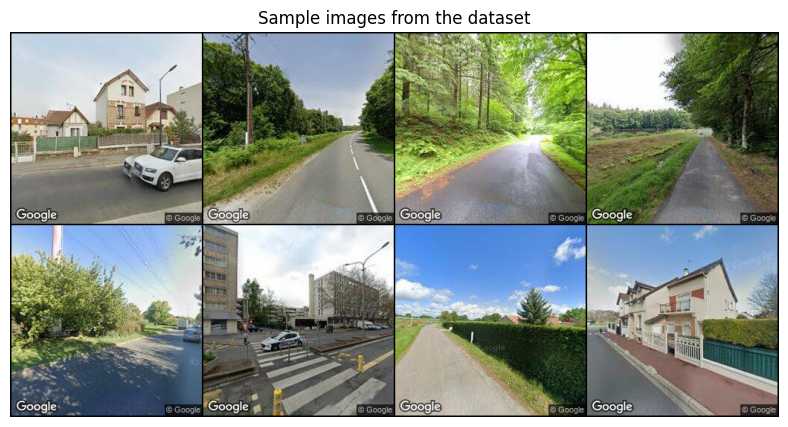

In [8]:
# Class names from the dataset
class_names = north_dataset.classes

# Create a DataLoader to sample a few images
from torch.utils.data import DataLoader

loader = DataLoader(north_dataset, batch_size=8, shuffle=True)

# Get one batch of images
images, labels = next(iter(loader))

# Move images to CPU and convert to numpy
images = images.cpu()

# Create a grid of images
img_grid = torchvision.utils.make_grid(images, nrow=4)

# Convert to numpy for plotting
np_img = img_grid.numpy().transpose((1, 2, 0))

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(np_img)
plt.title("Sample images from the dataset")
plt.axis('off')

# Print labels
print("Labels:", [class_names[label] for label in labels])
plt.show()


## Question 1 :
>  Change the last layer of the resnet model so that its size fits the problem.

In [9]:
num_classes = len(north_dataset.classes)
print(num_classes) #The issue is that resnet18 has 1000 classes whereas our dataset only has 2. We must adapt the final layer
base_model.fc = nn.Linear(base_model.fc.in_features, num_classes)


2


In [10]:
assert (
    base_model.fc.out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.

## Question 2:
> Train the last layer of a randomly initialized resnet model. Provide a function precompute_features in `utils.py` that creates a new dataset from the features precomputed by the model.

Intermediate question :  Provide the training process in the notebook with training curve. Comment on the accuracy.

If the model is $f \circ g$ where $f$ is the last layer and $g$ is
the rest of the model, it is not necessary to recompute $g(x)$ at
each epoch as $g$ is fixed. Hence you can precompute $g(x)$ and
create a new dataset $\mathcal{X}_{\text{train}}' = \{(g(x_n),y_n)\}_{n\leq N_{\text{train}}}$

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import v2
from torchvision.transforms.v2 import CutMix

from utils import precompute_features
from IPython.display import Markdown

from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import torch.nn.functional as F

In [12]:
def evaluate(model, device, dataloader, num_classes = 2):
    model.to(device)
    model.eval()
    accuracy_metric = Accuracy(task="multiclass", num_classes=num_classes).to(device)

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            accuracy_metric.update(preds, labels)

    return accuracy_metric.compute().item()

In [13]:
def train(model, max_epoch, batch_size, loss_fcn, optimizer, train_loader, num_classes =2, cut_mix = False):

  model.to(device)
  model.train()

  epochs_list = []
  losses_list = []


  for epoch in range(max_epoch):
    losses = []
    for inputs, labels in train_loader:

      optimizer.zero_grad()

      inputs, labels = inputs.to(device), labels.to(device)

      outputs = model(inputs)

      labels = (F.one_hot(labels,num_classes=num_classes)).float()#convert labels to one-hot encoding to enable training with cross entropy

      #for later questions
      if cut_mix:
        cutmix = CutMix(num_classes=num_classes, alpha=0.3)
        inputs, labels = cutmix(inputs, labels)

      loss = loss_fcn(outputs,labels)
      loss.backward()

      optimizer.step()

      losses.append(loss.item())
    loss_data = np.array(losses).mean()
    losses_list.append(loss_data)
    epochs_list.append(epoch)
    if epoch % 5 == 0:
      print("Epoch {:05d} | Loss: {:.4f}".format(epoch + 1, loss_data))

  return epochs_list,losses_list

In [14]:
random_resnet = models.resnet18(weights = None) #modern equivalent of pretrained = False

#adapt resnet to the north_dataset
num_classes = len(north_dataset.classes)
random_resnet.fc = nn.Linear(random_resnet.fc.in_features, num_classes)

precomputed_train_dataset = precompute_features(random_resnet,north_dataset, device)
precomputed_test_dataset = precompute_features(random_resnet,test_dataset, device)

batch_size = 10
max_epoch = 200

train_loader = DataLoader(dataset = precomputed_train_dataset, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(dataset = precomputed_test_dataset, batch_size = batch_size, shuffle = False)

last_layer = base_model.fc

optimizer = torch.optim.Adam(last_layer.parameters(), lr = 0.005)
loss_fcn = nn.BCEWithLogitsLoss()#binary since dataset has two classes

epochs_list,losses_list = train(last_layer, max_epoch, batch_size, loss_fcn, optimizer, train_loader)

precomputing dataset: 100%|██████████| 5/5 [00:00<00:00, 23.47it/s]


Epoch 00001 | Loss: 0.5735
Epoch 00006 | Loss: 0.5622
Epoch 00011 | Loss: 0.5516
Epoch 00016 | Loss: 0.5314
Epoch 00021 | Loss: 0.5444
Epoch 00026 | Loss: 0.6020
Epoch 00031 | Loss: 0.6081
Epoch 00036 | Loss: 0.6224
Epoch 00041 | Loss: 0.7847
Epoch 00046 | Loss: 0.5598
Epoch 00051 | Loss: 0.5124
Epoch 00056 | Loss: 0.4927
Epoch 00061 | Loss: 0.4878
Epoch 00066 | Loss: 0.5091
Epoch 00071 | Loss: 0.4813
Epoch 00076 | Loss: 0.5579
Epoch 00081 | Loss: 0.5308
Epoch 00086 | Loss: 0.4771
Epoch 00091 | Loss: 0.4762
Epoch 00096 | Loss: 0.4626
Epoch 00101 | Loss: 0.5961
Epoch 00106 | Loss: 0.4586
Epoch 00111 | Loss: 0.5207
Epoch 00116 | Loss: 0.4381
Epoch 00121 | Loss: 0.4354
Epoch 00126 | Loss: 0.4614
Epoch 00131 | Loss: 0.4660
Epoch 00136 | Loss: 0.4644
Epoch 00141 | Loss: 0.4214
Epoch 00146 | Loss: 0.4412
Epoch 00151 | Loss: 0.4954
Epoch 00156 | Loss: 0.5073
Epoch 00161 | Loss: 0.5280
Epoch 00166 | Loss: 0.4594
Epoch 00171 | Loss: 0.3908
Epoch 00176 | Loss: 0.4063
Epoch 00181 | Loss: 0.4571
E

In [15]:
def test_model(model, model_name, epochs_list,losses_list, train_loader,test_loader):

  plt.plot(epochs_list, losses_list)
  plt.title("Training loss")
  plt.xlabel("epochs")
  plt.ylabel("training loss")
  plt.legend()
  plt.show()

  epochs = len(epochs_list)
  train_acc = evaluate(model, device,train_loader, num_classes = 2)*100
  test_acc = evaluate(model, device,test_loader, num_classes = 2)*100

  table = f"""
  | Model    | Number of epochs | Train accuracy | Test accuracy |
  |----------|------------------|----------------|---------------|
  | {model_name} | {epochs}              | {train_acc:.2f}%        | {test_acc:.2f}%        |
  """

  display(Markdown(table))

<ipython-input-15-d9b47c91c2ed>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


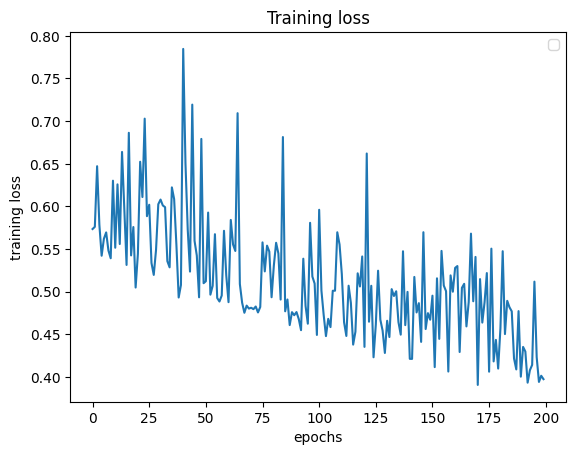


  | Model    | Number of epochs | Train accuracy | Test accuracy |
  |----------|------------------|----------------|---------------|
  | ResNet18 random initialisation trained last layer | 200              | 73.81%        | 50.00%        |
  

In [16]:
model_name = "ResNet18 random initialisation trained last layer"
test_model(last_layer, model_name, epochs_list,losses_list, train_loader,test_loader)

**The training is chaotic, with the test accuracy  at 50%. (if we plotted it during training we would see it oscillate around 50% inconsistently). The model does not suceed in learning even though  it learns to overfit on the training data.**

**With a randomly initialised resnet, we are basically trying to learn how to classify with random inputs and one layer. We cannot hope to detect structure and really learn representations of the images with this.**

**We could have hoped that even with random inputs, the structure of the resnet would have been a sufficient a priori, but apparently not.**

## Question 3 :
> Now start from a pretained model on Imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve.

 Provide two files : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a file  `utils.py` containing only the last layer class `LastLayer` inheriting from `torch.nn.Module` architecture of your final model to load
 -  a `last_layer_finetune.pth` file containing __only the last layer weights__ ( we will check the size)

 We will test your model on final accuracy on a test set.


In [17]:
from utils import LastLayer

pretrained_resnet = models.resnet18(weights="DEFAULT")

fc = LastLayer()  # !  Important : No argument

#adapt resnet to the north_dataset
num_classes = len(north_dataset.classes)
pretrained_resnet.fc = fc

precomputed_train_dataset = precompute_features(pretrained_resnet,north_dataset, device)
precomputed_test_dataset = precompute_features(pretrained_resnet,test_dataset, device)

batch_size = 10
max_epoch = 200

train_loader = DataLoader(dataset = precomputed_train_dataset, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(dataset = precomputed_test_dataset, batch_size = batch_size, shuffle = False)

optimizer = torch.optim.Adam(fc.parameters(), lr = 0.005)
loss_fcn = nn.BCEWithLogitsLoss()#binary since dataset has two classes

epochs_list,losses_list = train(fc, max_epoch, batch_size, loss_fcn, optimizer, train_loader)

torch.save(fc.state_dict(), "lastlayer.pth")

precomputing dataset: 100%|██████████| 5/5 [00:00<00:00, 34.96it/s]


Epoch 00001 | Loss: 0.5233
Epoch 00006 | Loss: 0.1455
Epoch 00011 | Loss: 0.0698
Epoch 00016 | Loss: 0.0452
Epoch 00021 | Loss: 0.0330
Epoch 00026 | Loss: 0.0265
Epoch 00031 | Loss: 0.0182
Epoch 00036 | Loss: 0.0152
Epoch 00041 | Loss: 0.0147
Epoch 00046 | Loss: 0.0104
Epoch 00051 | Loss: 0.0125
Epoch 00056 | Loss: 0.0077
Epoch 00061 | Loss: 0.0072
Epoch 00066 | Loss: 0.0066
Epoch 00071 | Loss: 0.0061
Epoch 00076 | Loss: 0.0075
Epoch 00081 | Loss: 0.0106
Epoch 00086 | Loss: 0.0039
Epoch 00091 | Loss: 0.0057
Epoch 00096 | Loss: 0.0035
Epoch 00101 | Loss: 0.0033
Epoch 00106 | Loss: 0.0030
Epoch 00111 | Loss: 0.0026
Epoch 00116 | Loss: 0.0027
Epoch 00121 | Loss: 0.0024
Epoch 00126 | Loss: 0.0025
Epoch 00131 | Loss: 0.0040
Epoch 00136 | Loss: 0.0023
Epoch 00141 | Loss: 0.0020
Epoch 00146 | Loss: 0.0017
Epoch 00151 | Loss: 0.0022
Epoch 00156 | Loss: 0.0015
Epoch 00161 | Loss: 0.0015
Epoch 00166 | Loss: 0.0014
Epoch 00171 | Loss: 0.0014
Epoch 00176 | Loss: 0.0014
Epoch 00181 | Loss: 0.0013
E

<ipython-input-15-d9b47c91c2ed>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


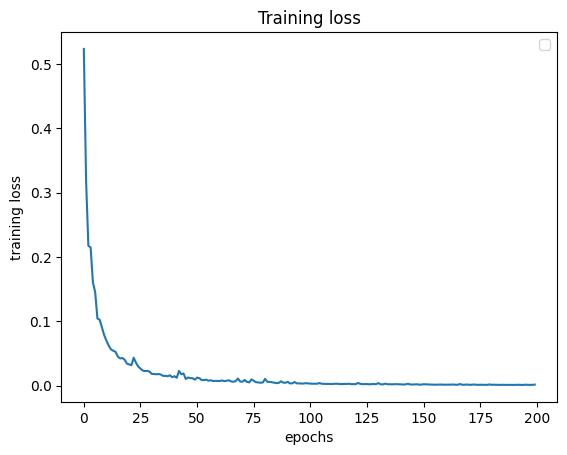


  | Model    | Number of epochs | Train accuracy | Test accuracy |
  |----------|------------------|----------------|---------------|
  | Pretrained ResNet18 finetuned  last layer | 200              | 100.00%        | 76.19%        |
  

In [18]:
model_name = "Pretrained ResNet18 finetuned  last layer"
test_model(fc, model_name, epochs_list,losses_list, train_loader,test_loader)

**Here we observe that by just training the  final layer, starting with a pretrained resnet, the training is much smoother. The model learns to perfectly ovefit the training set, with an improved test accuracy compared to the random case.**

In [19]:
fc.load_state_dict(torch.load("lastlayer.pth", weights_only=True))
pretrained_resnet.fc = fc
pretrained_resnet.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Question 4 :
> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  (We are perfectly fine if you use an external library **for this question only**, and of course use it in the next questions). (Warning : without data augmentation it may not improve the accuracy.)

Intermediate question : Describe LoRA. There are different ways of implementing LoRa for convolutions. You can choose your preferred one. Explain the version of LoRa you used, provide a drawing of the process in the `drawing_lora.png` file. (Hint: you can obtain a small rank convolution by combining a convolution and a 1x1 convolution. One of the two goes from a higher number of channels to a lower number of channels and the other one restores the number of channels.)

LoRA is a finetuning framework designed initially for transformers. It is based on the assumption that finetuning will induce low rank modifications of the original matrices.

The pretrained parameters are frozen and, to a given pretrained matrix $W \in \mathbb{R}^{d_{in},d_{out}}$ we add a low rank matrix $\Delta W$ constructed as $\Delta W = AB$ with $ A\in \mathbb{R}^{d_{in}r}, B \in \mathbb{R}^{r,d_{out}}$ with $d_{in}>>r$, $d_{out}>>r$

A scaling term $\frac{\alpha}{r}$ is introduced in the sum (often =1).

The parameters of $\Delta W$ are then trained (which is easier than retraining the full network since there are fewer parameters to load into the GPU).

At inference, the parameters are merged in $W' = W + \frac{\alpha}{r} \Delta W$ to not add overhead.

We will now try to adapt this to convolutional layers.


**Strategy**:

* Freeze all the parameters in model (except the first and last layers as in the LoRA-C paper https://arxiv.org/pdf/2410.16954)
  - first layer adapts to the new modality, the type of  data
  - last layer does the classification

* Define a new type of conv2d module which takes as input the original module, defines a new low rank convolution and sums it with original convolution (with a scaling)
* Identify all the modules using a conv2d in model and replace them with this new module.
*Train this new model on north_dataset

**Important precisions**

* Initialise the LoRA components such that it is zero initially (otherwise it risks throwing off the finetuning from the start if by misfortune $||\Delta C||>>||C||$
* Add dropout to the LoRA because  since there are few parameters, it does not benefit from the auto regularisation of deep learning models (is this the reason?)
* For inference, merge the model weights

* Eventually buffers and config tracking

**Defining the LoRA layer**

For intuition, we will not think in terms of rank but how we can build a convolution that has same input and output space but fewer degrees of freedom. This will make things easier than to try to visualise convolutions as matrices (which they are but it is not so easily seen in conv2D).

We want to define $\Delta C$ such that in a LoRA layer we compute $C(x) + \Delta C (x)$ with $\Delta C$ a convolution. We have to make sure the wieghts of $C$ and $\Delta C$ have the same shape so that $\Delta C (x)$ and $C (x)$ have the same shape.

A simple way to go about this is to first compute a $1\times1$ convolution $ A$ which preserves the weight and height of the output image but projecting onto fewer channels $r$. This introduces an information bottleneck which exactly corresponds to reduced degrees of freedom. Information has been lost in this compression onto $r$ features. But this is exactly what we want: a not so expressive convolution.

If we now define $B$ with the same hyperparameters as $C$ but $r$ input channels, and compose the two convolutions, we will get what we want. $A$ being $1 \times 1$ makes seeing this very easy since $A(x)$ has the same dimensions as $x$ with just fewer channels.

We wil then compute $C(x) + \frac{\alpha}{r} B \circ A (x)$

$\alpha$ is a fixed hyperparameter (usually equal to $r$). It is here because due to its fewer parameters $\Delta C$ will have a smalle norm than $C$ and hence will have less impact on gradients. We want to decorelate the impact of $r$ on expressive power and norm, hence the introduction of $\alpha$.

Notation remark: in this text,  $A, B, C$ denote convolution operations. In our implementation, $A$ and $B$ will be the parameters of Conv2d convolutions.

We now assimilate the weight matrix with the convolution operation for clarity.

**Refining the LoRA layer**

At inference, we do not want to add overhead so we don't want to have to compute both $C(x)$ and $\frac{\alpha}{r} B \circ A (x)$

Ideally we just want to compute a single convolution just as we would had we not fine-tuned the model.

For this reason we want to define $C'$ such that $C'(x) = C(x) + \frac{\alpha}{r} B \circ A (x)$

The main difficulty lies in writing  $B \circ A (x)$ as a single convolution $D$. This is made easier with the fact that $A$ is $1 \times 1$.

 We were able to find an analytic expression $B \circ A$. Using Einstein notation, considering $A \in \mathbb{R}^{r,c_{in},1,1}, B \in \mathbb{R}^{c_{out},r,k,k}$:

 $D_{mjlk} = A_{ijlk}B_{milk}$

 We provide an example below as well as a function `merge_conv_kernels` which generalises this composition of convolutions beyond $A$ a $1\times 1$ convolution.



In [20]:
kernel_size = 3; r = 2; in_channels = 5; out_channels = 7

#test image:
h = 10; w = 10;
img = torch.randn(in_channels,h,w)

#the original convolution C
conv = nn.Conv2d(in_channels, out_channels, kernel_size)

#the parameters of the two convolutions used to define \Delta C
A = nn.Parameter(torch.randn(r, in_channels, 1, 1))
B = nn.Parameter(torch.randn(out_channels, r, kernel_size, kernel_size))

#convolve the image with the A then B
c1 = torch.conv2d(img,A)
c2 = torch.conv2d(c1, B)

#define an equivalent D
D1 = torch.einsum('ijlk,cilk->cjlk', A, B)
c3 = torch.conv2d(img,D1)

# Compare the results
print((c2 - c3).abs().sum() < 1e-3)

#More general function

def merge_conv_kernels(k1, k2):
    """
    :input k1: A tensor of shape ``(out1, in1, s1, s1)``
    :input k2: A tensor of shape ``(out2, in2, s2, s2)``
    :returns: A tensor of shape ``(out2, in1, s1+s2-1, s1+s2-1)``
      so that convolving with it equals convolving with k1 and
      then with k2.
    """
    padding = k2.shape[-1] - 1
    # Flip because this is actually correlation, and permute to adapt to BHCW
    k3 = torch.conv2d(k1.permute(1, 0, 2, 3), k2.flip(-1, -2),
                      padding=padding).permute(1, 0, 2, 3)
    return k3

D2 = merge_conv_kernels(A,B)

# Compare the results
c4 = torch.conv2d(img,D2)
print((c2 - c4).abs().sum() < 1e-3)


tensor(True)
tensor(True)


In [21]:
def freeze_parameters(model,unfreeze_first_layer = False):
  '''freeze all parameters except first (optional) and last layers:
  '''
  # Freeze all parameters
  for param in model.parameters():
      param.requires_grad = False

  # Unfreeze first layer (conv1)
  if unfreeze_first_layer:
    for param in model.conv1.parameters():
        param.requires_grad = True

  # 3. Unfreeze last layer (fc)
  for param in model.fc.parameters():
      param.requires_grad = True

  for param in model.parameters():
      param.requires_grad = False

# LoRA conv2d layer

class LoRAConv2d(nn.Module):
    def __init__(self, original_conv, r, alpha, dropout_p = 0.1):
        super().__init__()

        in_channels = original_conv.in_channels
        out_channels = original_conv.out_channels
        kernel_size = (original_conv.kernel_size)[0]

        self.original_conv = original_conv
        self.scale = alpha / r

        self.stride = original_conv.stride
        self.padding = original_conv.padding
        self.dilation = original_conv.dilation

        self.dropout = nn.Dropout(p = dropout_p)

        # Low-rank LoRA approximation:
        self.A = nn.Parameter(torch.randn(r, in_channels, 1, 1))  # Conv: out, in, kH=1, kW=1--> preserves dimension of the 2D image with one channel
        self.B = nn.Parameter(torch.randn(out_channels, r, kernel_size, kernel_size))#having same kernel size is one way of making sure we get back the same size as the original convolution

        #initialisation
        nn.init.kaiming_uniform_(self.A, a=np.sqrt(5))
        nn.init.zeros_(self.B)

    def forward(self, x):
        D = torch.einsum('ijlk,milk->mjlk', self.A, self.B)
        lora_out = F.conv2d(x, D, stride=self.stride, padding=self.padding, dilation=self.dilation)#no need to match groups since no influence on  output size
        lora_out = self.dropout(lora_out)
        return self.original_conv(x) + self.scale*lora_out

def replace_conv_with_lora(model, r, alpha, unfreeze_first_layer = False):
  """
  Replace Conv2d layers with LoRAConv2d layers. Use recursivity to go through the hierarchical structure of modules and submodules
  At the class level of the model, it replaces convolutional layers( attributes of the model) by a new attribute with same name
  but a new value using setattr
  """
  for name, module in model.named_children():
      if unfreeze_first_layer and name == 'conv1':
        continue
      if isinstance(module, nn.Conv2d):
          setattr(model, name, LoRAConv2d(module, r=r, alpha=alpha))
      else:
          replace_conv_with_lora(module, r, alpha)

def replace_conv_with_lora_deep_layers(model, r, alpha):
    """
    Replace Conv2d layers with LoRAConv2d layers, but only in layer4.
    """
    for name, module in model.named_children():
        # Only recurse into layer3 and layer4
        if name in ['layer4']:
            for sub_name, sub_module in module.named_modules():
                if isinstance(sub_module, nn.Conv2d):
                    # Get parent module of this submodule
                    parent = module
                    path = sub_name.split(".")
                    for p in path[:-1]:
                        parent = getattr(parent, p)
                    # Replace conv2d with LoRAConv2d
                    setattr(parent, path[-1], LoRAConv2d(sub_module, r=r, alpha=alpha))


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



In [22]:
#Set up training

#adapt pretrained resnet to the north_dataset
lora_model = models.resnet18(weights="DEFAULT")
num_classes = len(north_dataset.classes)
lora_model.fc = nn.Linear(in_features = 512,out_features = 2)#still a resnet model

#Apply LoRA:
print(f"Trainable parameters before LoRA: {count_trainable_params(lora_model):,}")
freeze_parameters(lora_model)
replace_conv_with_lora_deep_layers(lora_model, r=1, alpha=1)
print(f"Trainable parameters after LoRA: {count_trainable_params(lora_model):,}")


Trainable parameters before LoRA: 11,177,538
Trainable parameters after LoRA: 20,992


In [23]:
#Train

#training parameters
batch_size = 10
max_epoch = 100
loss_fcn = nn.BCEWithLogitsLoss()#binary since dataset has two classes

#load data
train_loader = DataLoader(dataset = north_dataset, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)

#exclude non updated parameters from the optimiser's internal states
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, lora_model.parameters()), lr = 0.005)

#launch training
epochs_list,losses_list = train(lora_model, max_epoch, batch_size, loss_fcn, optimizer, train_loader)
torch.save(lora_model.state_dict(), "lora_resnet.pth")

Epoch 00001 | Loss: 0.7211
Epoch 00006 | Loss: 0.2034
Epoch 00011 | Loss: 0.3628
Epoch 00016 | Loss: 0.2264
Epoch 00021 | Loss: 0.2612
Epoch 00026 | Loss: 0.0410
Epoch 00031 | Loss: 0.1711
Epoch 00036 | Loss: 0.0230
Epoch 00041 | Loss: 0.3142
Epoch 00046 | Loss: 0.0458
Epoch 00051 | Loss: 0.0708
Epoch 00056 | Loss: 0.0586
Epoch 00061 | Loss: 0.2750
Epoch 00066 | Loss: 0.0797
Epoch 00071 | Loss: 0.0186
Epoch 00076 | Loss: 0.0703
Epoch 00081 | Loss: 0.0456
Epoch 00086 | Loss: 0.4443
Epoch 00091 | Loss: 0.0201
Epoch 00096 | Loss: 0.0864


In [24]:
#inference mode: we are going to merge the weights first for inference.

def merge_lora_conv2d(lora_module: LoRAConv2d) -> nn.Conv2d:
    assert isinstance(lora_module, LoRAConv2d), "Input must be a LoRAConv2d instance"

    # Get the original frozen weight
    C = lora_module.original_conv.weight.detach().clone()

    # Compute the low-rank correction
    D = torch.einsum('ijlk,milk->mjlk', lora_module.A, lora_module.B)

    # Merge LoRA correction
    merged_weight = C + lora_module.scale * D

    # Create a new nn.Conv2d layer with same settings
    bias = lora_module.original_conv.bias is not None
    new_conv = nn.Conv2d(
        in_channels=merged_weight.shape[1],
        out_channels=merged_weight.shape[0],
        kernel_size=merged_weight.shape[2:],
        stride=lora_module.stride,
        padding=lora_module.padding,
        dilation=lora_module.dilation,
        bias=bias
    )

    # Copy weights (and bias if present)
    with torch.no_grad():
        new_conv.weight.copy_(merged_weight)
        if bias:
            new_conv.bias.copy_(lora_module.original_conv.bias)

    return new_conv


def convert_model_to_merged(model: nn.Module) -> nn.Module:
    for name, module in model.named_children():
        if isinstance(module, LoRAConv2d):
            setattr(model, name, merge_lora_conv2d(module))
        else:
            convert_model_to_merged(module)
    return model



<ipython-input-15-d9b47c91c2ed>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


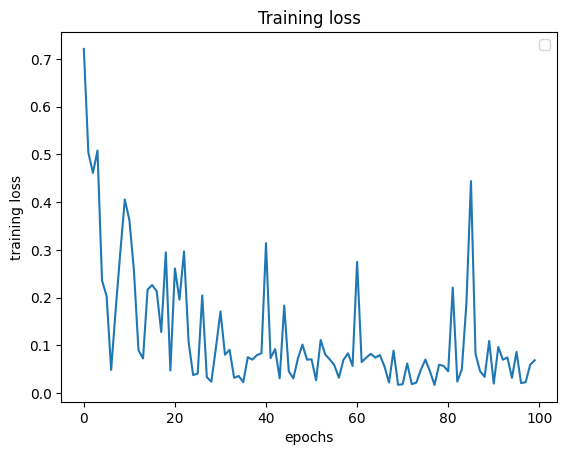


  | Model    | Number of epochs | Train accuracy | Test accuracy |
  |----------|------------------|----------------|---------------|
  | Pretrained ResNet18 with lora, r = 1 | 100              | 100.00%        | 78.57%        |
  

Merged lora model inference time:  0.35932421684265137


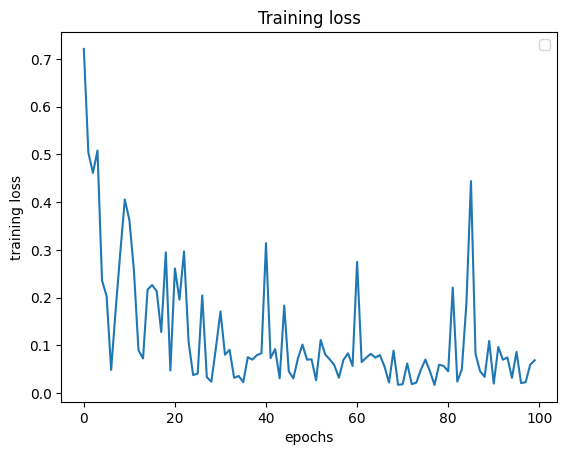


  | Model    | Number of epochs | Train accuracy | Test accuracy |
  |----------|------------------|----------------|---------------|
  | Pretrained ResNet18 with lora, r = 1 | 100              | 100.00%        | 78.57%        |
  

Unmerged lora model inference time:  0.3621945381164551


In [25]:
import copy
from time import time
lora_model_copy = copy.deepcopy(lora_model)
lora_model_merged = convert_model_to_merged(lora_model_copy)
model_name = "Pretrained ResNet18 with lora, r = 1"

#compare the merged and unmerged models
start = time()
test_model(lora_model_merged, model_name, epochs_list,losses_list, train_loader,test_loader)
end = time()
print("Merged lora model inference time: ",end-start)

start = time()
test_model(lora_model, model_name, epochs_list,losses_list, train_loader,test_loader)
end = time()
print("Unmerged lora model inference time: ", end-start)

## Question 5 :
In order to better train our LORA weights, let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them in your training pipeline.

 Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing `cutmix.png`.


  Provide one file : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a `daug_resnet.pth` file containing the weight of the ResNet18 after DAUG  (  !  It  has to be of the class ResNet so you have to merge LoRA weights with the ResNet18 weights)

In [26]:
## Data Augmentation
from torchvision.transforms import v2
from torchvision.transforms.v2 import CutMix

In [64]:
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF
from torch.utils.data import TensorDataset
import torch
from PIL import Image
import os

# Your augmentation transform (includes ToTensor at the end)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),  # Less aggressive crop
    transforms.RandomHorizontalFlip(p=0.5),               # Keep standard horizontal flip
    transforms.ColorJitter(0.1, 0.1, 0.1),                 # Softer color variation
    transforms.RandomRotation(degrees=5),                 # Smaller rotation angle
    transforms.ToTensor()
])


# Load raw images (no transform so we can get PIL Images)
north_dataset_raw = datasets.ImageFolder(
    dir_path + "north_dataset_sample"  # make sure this exists
    # No transform
)

# How many augmentations per image
N = 5

augmented_images = []
augmented_labels = []

# Loop through raw dataset to apply transformations
for img, label in north_dataset_raw:
    for _ in range(N):
        augmented_img = train_transform(img)  # img is PIL, train_transform expects PIL
        augmented_images.append(augmented_img)
        augmented_labels.append(label)

# Turn into a PyTorch dataset
train_dataset = TensorDataset(torch.stack(augmented_images), torch.tensor(augmented_labels))


In [71]:

print(len(north_dataset))
print(len(train_dataset))

#update train loaders
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

cutmix = CutMix(num_classes=2)


42
210


Labels: ['87', '87', '92', '92', '87', '87', '87', '87']


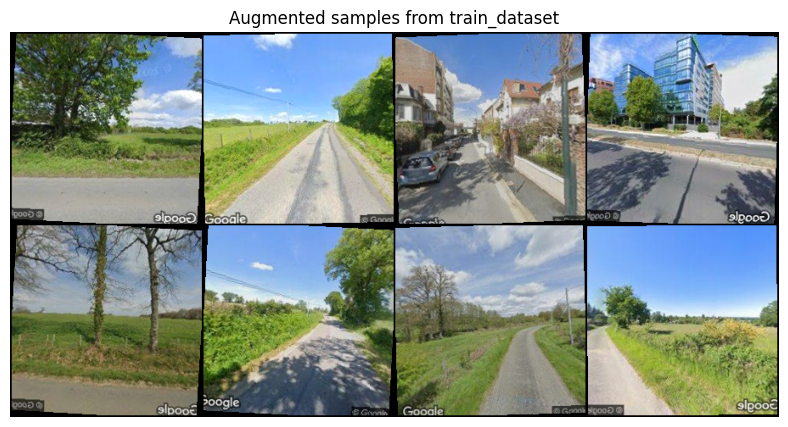

In [72]:
import matplotlib.pyplot as plt
import torchvision

# Class names (same order as in ImageFolder)
class_names = north_dataset_raw.classes

# Sample a few images from the dataset
from torch.utils.data import DataLoader

loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Get one batch
images, labels = next(iter(loader))

# Create image grid
img_grid = torchvision.utils.make_grid(images, nrow=4)

# Convert to numpy for plotting
np_img = img_grid.numpy().transpose((1, 2, 0))

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(np_img)
plt.title("Augmented samples from train_dataset")
plt.axis('off')

# Print labels
print("Labels:", [class_names[label] for label in labels])
plt.show()


In [73]:
#Set up training

#adapt pretrained resnet to the north_dataset
daug_lora_model = models.resnet18(weights="DEFAULT")
num_classes = len(north_dataset.classes)
daug_lora_model.fc = nn.Linear(in_features = 512,out_features = 2)#still a resnet model

#Apply LoRA with an unfrozen first layer
print(f"Trainable parameters before LoRA: {count_trainable_params(daug_lora_model):,}")
freeze_parameters(daug_lora_model, unfreeze_first_layer= False)
replace_conv_with_lora_deep_layers(daug_lora_model, r=1, alpha=1)
print(f"Trainable parameters after LoRA: {count_trainable_params(daug_lora_model):,}")


Trainable parameters before LoRA: 11,177,538
Trainable parameters after LoRA: 20,992


In [74]:
#Train

#training parameters

max_epoch = 100
loss_fcn = nn.BCEWithLogitsLoss()#binary since dataset has two classes

#exclude non updated parameters from the optimiser's internal states
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, daug_lora_model.parameters()), lr = 1e-4)

#launch training with CutMix
epochs_list,losses_list = train(daug_lora_model, max_epoch, batch_size, loss_fcn, optimizer, train_loader, cut_mix = True)
torch.save(lora_model.state_dict(), "daug_resnet.pth")

Epoch 00001 | Loss: 0.6716
Epoch 00006 | Loss: 0.6379
Epoch 00011 | Loss: 0.5614
Epoch 00016 | Loss: 0.5244
Epoch 00021 | Loss: 0.5639
Epoch 00026 | Loss: 0.5189
Epoch 00031 | Loss: 0.5127
Epoch 00036 | Loss: 0.4400
Epoch 00041 | Loss: 0.4119
Epoch 00046 | Loss: 0.5051
Epoch 00051 | Loss: 0.4335
Epoch 00056 | Loss: 0.4344
Epoch 00061 | Loss: 0.5546
Epoch 00066 | Loss: 0.5892
Epoch 00071 | Loss: 0.4895
Epoch 00076 | Loss: 0.4164
Epoch 00081 | Loss: 0.3990
Epoch 00086 | Loss: 0.3993
Epoch 00091 | Loss: 0.4706
Epoch 00096 | Loss: 0.4355


In [32]:
assert isinstance(daug_lora_model, models.ResNet)

<ipython-input-15-d9b47c91c2ed>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


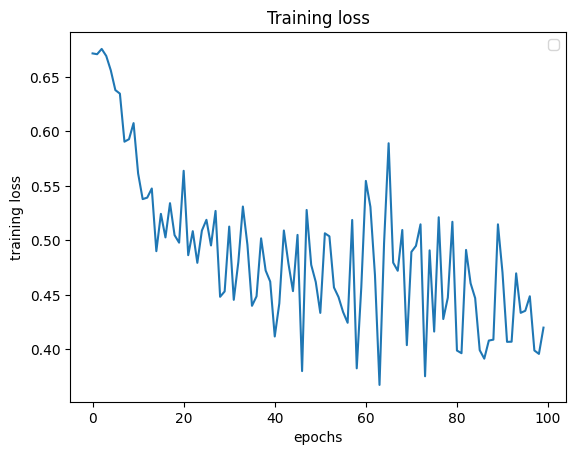


  | Model    | Number of epochs | Train accuracy | Test accuracy |
  |----------|------------------|----------------|---------------|
  | Pretrained ResNet18 with lora and daug, r = 1 | 100              | 100.00%        | 80.95%        |
  

In [75]:
daug_lora_model_copy = copy.deepcopy(daug_lora_model)
daug_lora_model_merged = convert_model_to_merged(daug_lora_model_copy)
model_name = "Pretrained ResNet18 with lora and daug, r = 1"

test_model(daug_lora_model_merged, model_name, epochs_list,losses_list, train_loader,test_loader)


## Question 6 : (BONUS)
> Do the best you can : improve performance on test set while keeping ResNet 18 architecture, or decrease the size of the model

Provide a file  `final_model.pth` containing the weights of the final model and provide the class `FinalModel()` in the `utils.py` file.

I tried doing this in question 5 in daug.

Here are the strategies I followed
- Since the model tended to have 100% accuracy on the train set, it was clearly overfitting and hence finding it difficult to learn useful optimisation directions. I tried to make learning a little harder (dropout, increased dataset, altered dataset)but then, not only was the loss chaotic but also high.
- I tried not only enriching the training dataset with transforms but increase its size up to tenfold (420): it however made training longer without a clear improvement in performance.
- I tried to shrink the model by freezing all layers and only introducing lora convolutions in the last block layer 4 of resnet18. This brought me from 40 000 to 20 000 parameters but still did not improve performance so much.
- I tried to play on the learning rate to make things smoother by reducing the learning rate.
- I tried to lower the difficulty of the cutmix (which i left at 0.3) or the raidcality of the transforms (smaller angles, less noise), hoping it would make learning not too hard.

The main avenue I would consider further would be to try to shrink the model further because 42 original images for 20 000 parameters is a huge gap.